# [프로젝트] 여행 지출 금액 회귀 및 분류 머신러닝

---

## 프로젝트 개요

여행 계획을 세울 때 여행 경비를 미리 가늠하기가 쉽지 않아서 고민한 경험이 있으실 텐데요.

> "여행 목적, 여행 스타일 등 다양한 여행객 정보들을 통해 예상 지출 금액을 예측할 수 있을까?"

이번 프로젝트에서는 수도권 여행로그 데이터를 활용하여 여행 지출 금액 회귀 및 분류 머신러닝을 실습합니다.

---

## 프로젝트 목표

- 수도권 여행로그 데이터를 바탕으로 여행 지출 금액 회귀 분석 및 고지출 여행객 분류 모델 학습
- 회귀 및 분류 머신러닝을 위한 탐색적 데이터 분석, 데이터 전처리, 모델 선택 및 최적화 기법 등 머신러닝 기초 학습

---

## 데이터 출처

AI Hub - 국내 여행로그 데이터(수도권)     
https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71581

---

## 목차

1. 데이터 불러오기
2. 탐색적 데이터 분석 (EDA)
3. 데이터 전처리
4. 여행 지출 금액 회귀 모델
5. 고지출 여행객 분류 모델

---

## 1. 데이터 불러오기

이번 프로젝트에 필요한 라이브러리를 불러옵니다.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='NanumGothic')
import matplotlib.font_manager as fm
from collections import Counter

분석에 사용할 데이터는 수도권 여행로그 데이터입니다.     
여행로그는 아래와 같이 세부 유형의 데이터로 구분되어 있습니다.

- 코드 (행정동 번호, 각 카테고리별 라벨 정보 등)
- 여행 (여행 목적 등)
- 여행객 (여행객 정보, 여행 스타일 등)
- 이동 소비 내역
- 활동 소비 내역
- 숙박 소비 내역
- 사전 소비 내역

자세한 데이터 구조는 [링크](https://www.aihub.or.kr/web-nas/aihub21/files/editor/2023/07/b52b31dc68bf41708e6caa7a999a63a1.png)를 통해 확인하실 수 있습니다.

![설명 텍스트](https://aihub.or.kr/web-nas/aihub21/files/editor/2023/07/36ef970d172040699271937b73aeecef.png)

이번 프로젝트에서는 **여행객 정보를 바탕으로 '여행 지출 금액 예측' 및 '고지출 여행객 분류' 머신러닝**을 수행할 예정입니다.    
위 데이터에서 회귀 및 분류 모델의 독립/종속변수로 사용할 컬럼은 다음과 같습니다.

> 독립변수:
> - 여행 목적, 기간 등 여행 관련 정보
> - 성별, 가족, 여행 스타일 등 여행객 관련 정보
>
> 종속변수:
> - 이동/활동/숙박/사전 소비 총 금액

먼저 독립변수로 사용할 데이터들을 확인해 볼까요?      
여행 데이터에는 해당 여행을 떠난 여행객 ID, 여행 목적, 여행 기간 등의 정보가 담겨있습니다.

In [2]:
# 여행 데이터 불러오기
travel_df = pd.read_csv('data/tn_travel.csv', encoding='utf-8')
travel_df.head()

,TRAVEL_ID,TRAVEL_NM,TRAVELER_ID,TRAVEL_PURPOSE,TRAVEL_START_YMD,TRAVEL_END_YMD,MVMN_NM,TRAVEL_PERSONA,TRAVEL_MISSION,TRAVEL_MISSION_CHECK
0,a_a014262,A03,a014262,1;11;2;22;,2022-10-29,2022-10-30,자가용,NaN,1;11;2;22;,2;1;22
1,a_a006728,A03,a006728,21;24;5;22;26;27;,2022-10-10,2022-10-11,자가용,NaN,21;24;5;22;26;27;,6;1;22
2,a_a015745,A02,a015745,1;2;6;,2022-10-31,2022-11-03,대중교통 등,NaN,1;2;6;,13;3;28
3,a_a010544,A03,a010544,21;22;24;26;,2022-11-01,2022-11-02,자가용,NaN,21;22;24;26;,1;22;26
4,a_a012058,A03,a012058,1;4;10;12;21;22;26;,2022-11-05,2022-11-06,대중교통 등,수도권 외 거주 39세 이하 커플,1;4;10;12;21;22;26;,1;21;22


여행객 데이터에서는 각 여행객의 신상 정보와 여행 스타일, 여행 동기 등의 정보를 확인할 수 있습니다.

In [3]:
# 여행객 데이터 불러오기
traveler_df = pd.read_csv('data/tn_traveller_master.csv', encoding='utf-8')
traveler_df.head()

,TRAVELER_ID,RESIDENCE_SGG_CD,GENDER,AGE_GRP,EDU_NM,EDU_FNSH_SE,MARR_STTS,FAMILY_MEMB,JOB_NM,JOB_ETC,...,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_STATUS_RESIDENCE,TRAVEL_STATUS_DESTINATION,TRAVEL_STATUS_ACCOMPANY,TRAVEL_STATUS_YMD,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_COMPANIONS_NUM
0,b015583,41,여,20,6,1.0,1.0,5,3.0,NaN,...,1,7,경기도,충남,2인 여행(가족 외),2022-10-29~2022-10-30,1,NaN,NaN,1
1,a001105,30,남,30,6,1.0,1.0,2,3.0,NaN,...,6,5,대전광역시,경기,3인 이상 여행(가족 외),2022-09-03~2022-09-04,3,NaN,NaN,7
2,a001673,41,여,30,4,1.0,2.0,3,NaN,1.0,...,2,7,경기도,서울,자녀 동반 여행,2022-09-18~2022-09-19,10,7.0,1.0,2
3,a017690,41,여,30,6,1.0,1.0,3,3.0,NaN,...,4,5,경기도,서울,3인 이상 여행(가족 외),2022-11-12~2022-11-12,3,1.0,2.0,3
4,c006666,28,여,30,6,1.0,1.0,3,13.0,NaN,...,5,5,인천광역시,경기,나홀로 여행,2022-10-18~2022-10-18,1,7.0,2.0,0


다음으로 종속변수로 사용할 데이터들을 살펴보겠습니다.     
활동/이동/숙박/사전 소비 내역 데이터에서 종속변수로 활용할 컬럼은 `PAYMENT_AMT_WON`입니다.     
각 여행별 지출 내역이 원 단위로 표기되어 있습니다.

In [4]:
# 활동 소비 내역 데이터 불러오기
activity_df = pd.read_csv('data/tn_activity_consume_his.csv', encoding='utf-8')
activity_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']].head()

,TRAVEL_ID,PAYMENT_AMT_WON
0,a_a004739,22000.0
1,a_a002397,33000.0
2,a_a017904,31400.0
3,a_a018111,48000.0
4,a_a005012,10000.0


In [ ]:
# 이동 소비 내역 데이터 불러오기
move_df = pd.read_csv('data/tn_mvmn_consume_his.csv', encoding='utf-8')
move_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']].head()

,TRAVEL_ID,PAYMENT_AMT_WON
0,a_a000279,70000
1,a_a004250,50000
2,a_a003984,0
3,a_a000336,11000
4,a_a014619,10000


In [ ]:
# 숙박 소비 내역 데이터 불러오기
lodge_df = pd.read_csv('data/tn_lodge_consume_his.csv', encoding='utf-8')
lodge_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']].head()

,TRAVEL_ID,PAYMENT_AMT_WON
0,a_a000290,160000
1,a_a000805,100000
2,a_a012504,36000
3,a_a001356,102460
4,a_a003139,340000


In [ ]:
# 사전 소비 내역 데이터 불러오기
pre_expense_df = pd.read_csv('data/tn_adv_consume_his.csv', encoding='utf-8')
pre_expense_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']].head()

,TRAVEL_ID,PAYMENT_AMT_WON
0,a_a007376,10000
1,a_a000122,6800
2,a_a003807,81000
3,a_a009440,69800
4,a_a017885,39990


이렇게 이번 프로젝트에서 사용할 데이터들을 모두 불러왔습니다.     
다음 챕터에서는 탐색적 데이터 분석을 수행하며 데이터를 이해하고 어떻게 전처리할지 고민해 보도록 하겠습니다. 

---

## 2. 탐색적 데이터 분석 (EDA)

이번 챕터에서는 독립변수와 종속변수로 사용할 정보들의 분포를 살펴보겠습니다.

### 2.1. 여행 데이터 분석

먼저 여행 목적과 여행 미션 관련 정보들을 살펴볼까요?     
`TRAVEL_PURPOSE`와 `TRAVEL_MISSION` 컬럼은 각 여행별로 어떤 목적과 미션들을 가지고 있는지에 대한 정보를 담고 있습니다.

In [8]:
# 여행 목적
travel_df[['TRAVEL_ID', 'TRAVEL_PURPOSE']].head()

,TRAVEL_ID,TRAVEL_PURPOSE
0,a_a014262,1;11;2;22;
1,a_a006728,21;24;5;22;26;27;
2,a_a015745,1;2;6;
3,a_a010544,21;22;24;26;
4,a_a012058,1;4;10;12;21;22;26;


In [9]:
# 여행 미션
travel_df[['TRAVEL_ID', 'TRAVEL_MISSION']].head()

,TRAVEL_ID,TRAVEL_MISSION
0,a_a014262,1;11;2;22;
1,a_a006728,21;24;5;22;26;27;
2,a_a015745,1;2;6;
3,a_a010544,21;22;24;26;
4,a_a012058,1;4;10;12;21;22;26;


여러 숫자 라벨이 세미콜론(;)으로 구분되어 하나의 텍스트로 저장되어 있네요.     
각 숫자 라벨이 어떤 코드를 의미하는지 살펴보기 위해 코드 정보 데이터를 불러와 확인해 봅시다.

In [ ]:
# 코드 정보 데이터 불러오기
code_df = pd.read_csv('data/tc_codeb.csv', encoding='utf-8')

# 여행 목적 및 미션 코드 정보
code_df.loc[code_df['cd_a'] == 'MIS', ['cd_b', 'cd_nm']]

,cd_b,cd_nm
105,1,쇼핑
106,2,"테마파크, 놀이시설, 동/식물원 방문"
107,3,역사 유적지 방문
108,4,시티투어
109,5,"야외 스포츠, 레포츠 활동"
110,6,지역 문화예술/공연/전시시설 관람
111,7,유흥/오락(나이트라이프)
112,8,캠핑
113,9,지역 축제/이벤트 참가
114,10,온천/스파


예를 들어 `22;23;`라는 값은 `[SNS 인생샷 여행, 호캉스 여행]`을 의미합니다.

이제 각 라벨별 등장 횟수를 시각화해 볼까요?     
x축에 표시될 라벨들이 텍스트로 표시될 수 있도록 코드를 매핑하는 과정을 거칩니다.

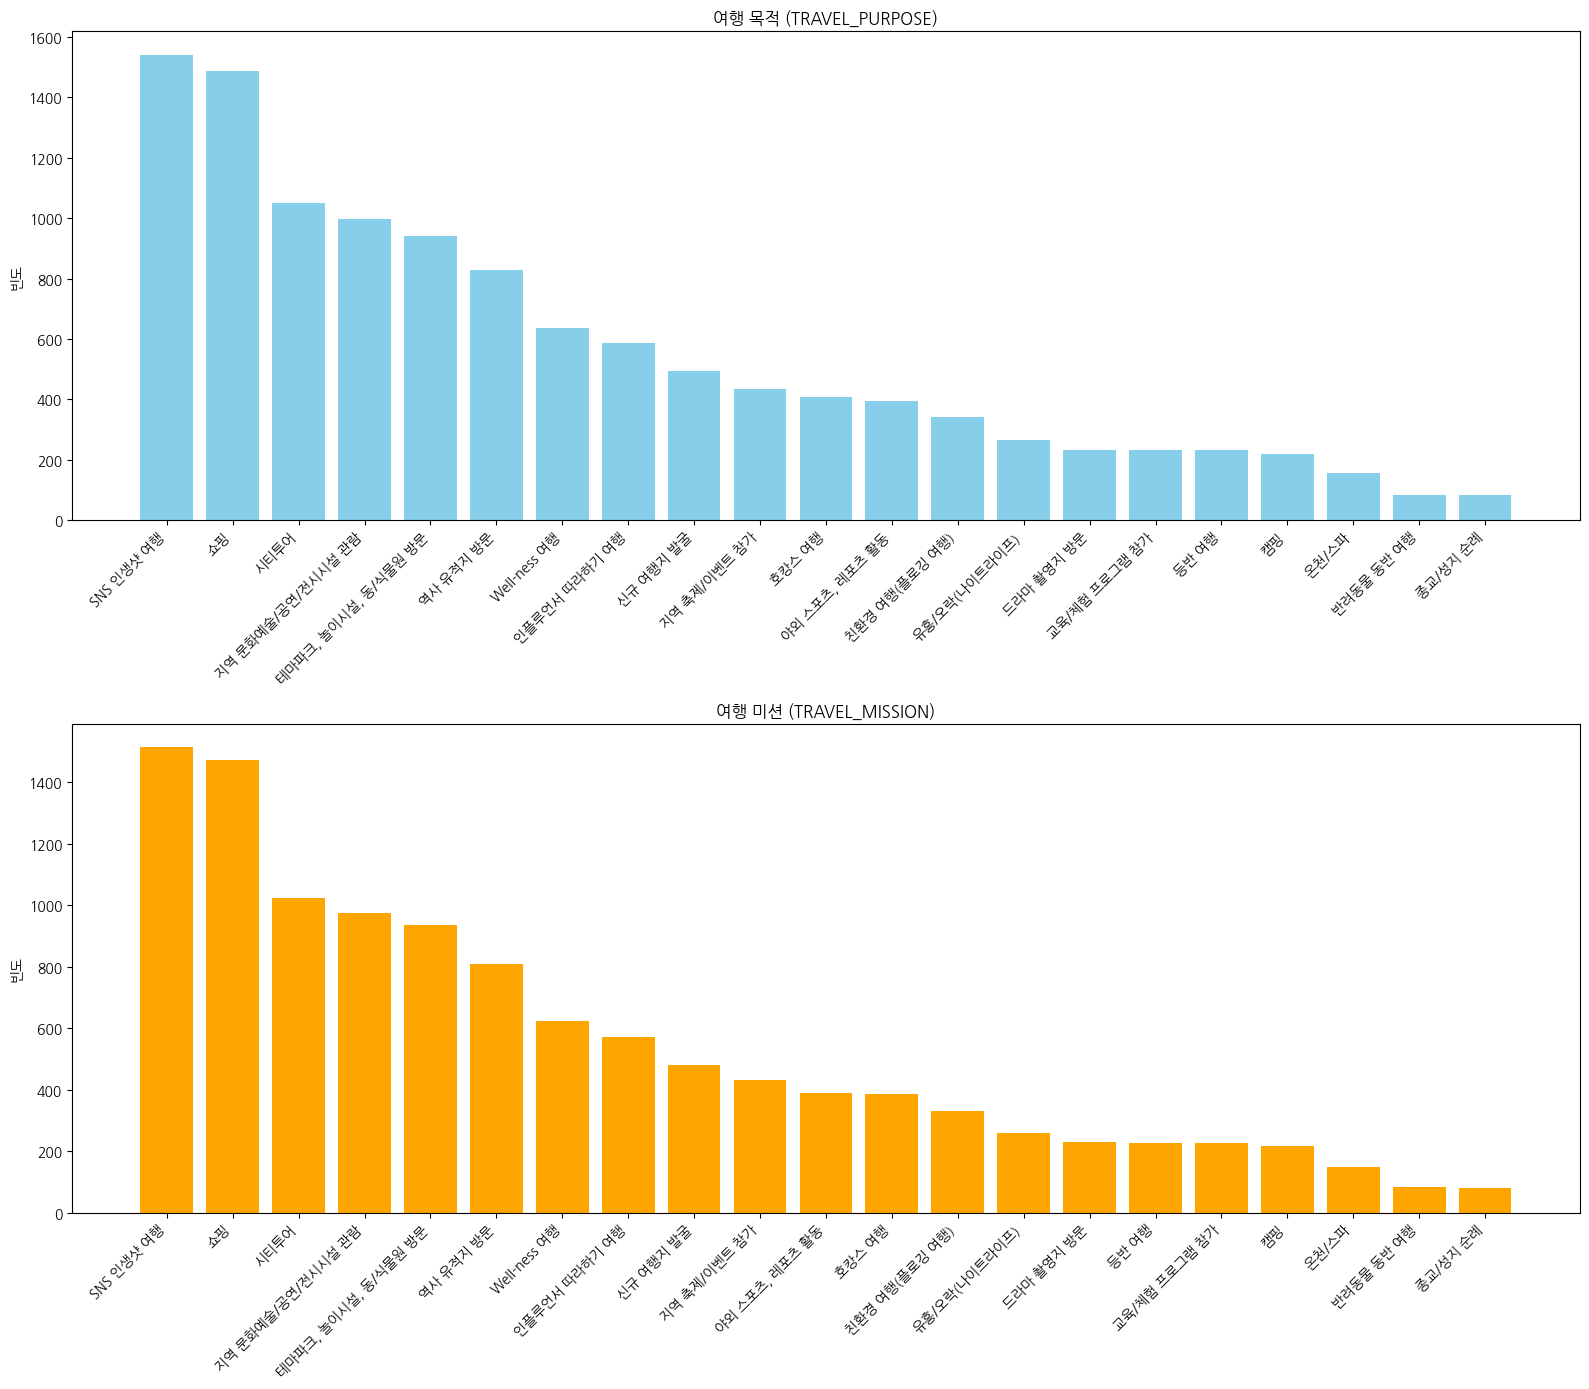

In [11]:
# PURPOSE 컬럼의 라벨 리스트화 및 개수 계산
travel_purposes = travel_df['TRAVEL_PURPOSE'].dropna().apply(lambda x: x.strip(';').split(';'))
flat_purposes = [int(purpose) for sublist in travel_purposes for purpose in sublist]
purpose_counts = Counter(flat_purposes)

# MISSION 컬럼의 라벨 리스트화 및 개수 계산
travel_missions = travel_df['TRAVEL_MISSION'].dropna().apply(lambda x: x.strip(';').split(';'))
flat_missions = [int(mission) for sublist in travel_missions for mission in sublist]
mission_counts = Counter(flat_missions)

# 코드 텍스트 매핑
code_map_df = code_df[code_df['cd_a'] == 'MIS']
code_map = dict(zip(code_map_df['cd_b'].astype(int), code_map_df['cd_nm']))

# PURPOSE 컬럼의 라벨별 개수 정렬 (내림차순)
purpose_sorted = sorted(purpose_counts.items(), key=lambda x: x[1], reverse=True)
purpose_labels = [code_map.get(code, str(code)) for code, _ in purpose_sorted]
purpose_values = [count for _, count in purpose_sorted]

# MISSION 컬럼의 라벨별 개수 정렬 (내림차순)
mission_sorted = sorted(mission_counts.items(), key=lambda x: x[1], reverse=True)
mission_labels = [code_map.get(code, str(code)) for code, _ in mission_sorted]
mission_values = [count for _, count in mission_sorted]

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
axes[0].bar(range(len(purpose_labels)), purpose_values, color='skyblue')
axes[0].set_title('여행 목적 (TRAVEL_PURPOSE)')
axes[0].set_ylabel('빈도')
axes[0].set_xticks(range(len(purpose_labels)))
axes[0].set_xticklabels(purpose_labels, rotation=45, ha='right')
axes[1].bar(range(len(mission_labels)), mission_values, color='orange')
axes[1].set_title('여행 미션 (TRAVEL_MISSION)')
axes[1].set_ylabel('빈도')
axes[1].set_xticks(range(len(mission_labels)))
axes[1].set_xticklabels(mission_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

여행 목적과 미션 모두 순위가 거의 비슷하네요.   
`SNS 인생샷 여행`, `쇼핑` 등의 목적으로 떠나는 여행이 가장 많은 것을 확인할 수 있습니다.

이번에는 여행 기간의 분포를 살펴보겠습니다.     
여행 시작일과 종료일을 나타내는 `TRAVEL_START_YMD`, `TRAVEL_END_YMD` 컬럼 값을 활용하여 여행 기간(일)을 새롭게 계산하고, 여행 기간의 빈도를 시각화해 볼까요?

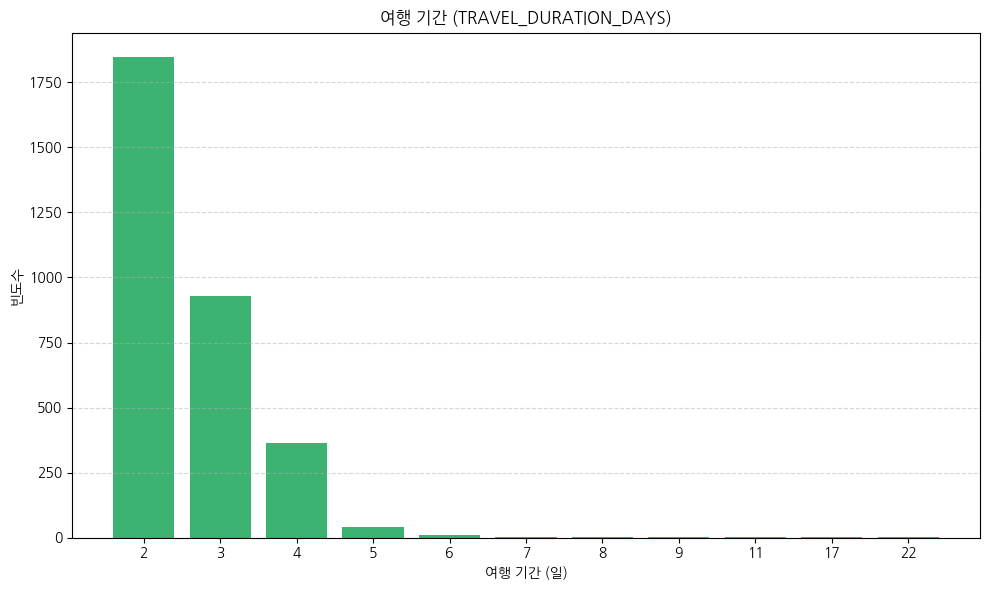

In [17]:
travel_df_copy = travel_df.copy()

# 여행 기간(일) 계산
travel_df_copy['TRAVEL_START_YMD'] = pd.to_datetime(travel_df_copy['TRAVEL_START_YMD'])
travel_df_copy['TRAVEL_END_YMD'] = pd.to_datetime(travel_df_copy['TRAVEL_END_YMD'])
travel_df_copy['TRAVEL_DURATION_DAYS'] = (travel_df_copy['TRAVEL_END_YMD'] - travel_df_copy['TRAVEL_START_YMD']).dt.days + 1

# 빈도 계산 및 내림차순 정렬
duration_counts = travel_df_copy['TRAVEL_DURATION_DAYS'].value_counts().sort_index()
x_labels = [str(i) for i in duration_counts.index]

# 시각화
plt.figure(figsize=(10, 6))
plt.bar(x_labels, duration_counts.values, color='mediumseagreen')
plt.title('여행 기간 (TRAVEL_DURATION_DAYS)')
plt.xlabel('여행 기간 (일)')
plt.ylabel('빈도수')
plt.xticks(x_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

여행 기간의 분포를 살펴보면 2 ~ 4일 정도의 여행이 대부분인 것을 확인할 수 있네요. 

---

### 2.2. 여행객 데이터 분석

이번에는 여행객 데이터를 분석해보겠습니다.     
먼저 여행객의 성별, 연령대, 학력, 가족 구성원 수 정보를 살펴봅시다.     
`EDU_NM`의 학력 정보는 다음과 같은 라벨로 구성되어 있습니다.

In [18]:
# 학력 정보 코드
code_df.loc[code_df['cd_a'] == 'EDU', ['cd_b', 'cd_nm']]

,cd_b,cd_nm
126,1,무학
127,2,초등학교
128,3,중학교
129,4,고등학교
130,5,대학(4년제 미만)
131,6,대학교(4년제 이상)
132,7,대학원 석사 과정
133,8,대학원 박사 과정


`GENDER`, `AGE_GRP`, `EDU_NM`, `FAMILY_MEMB` 분포를 시각화해 볼까요?

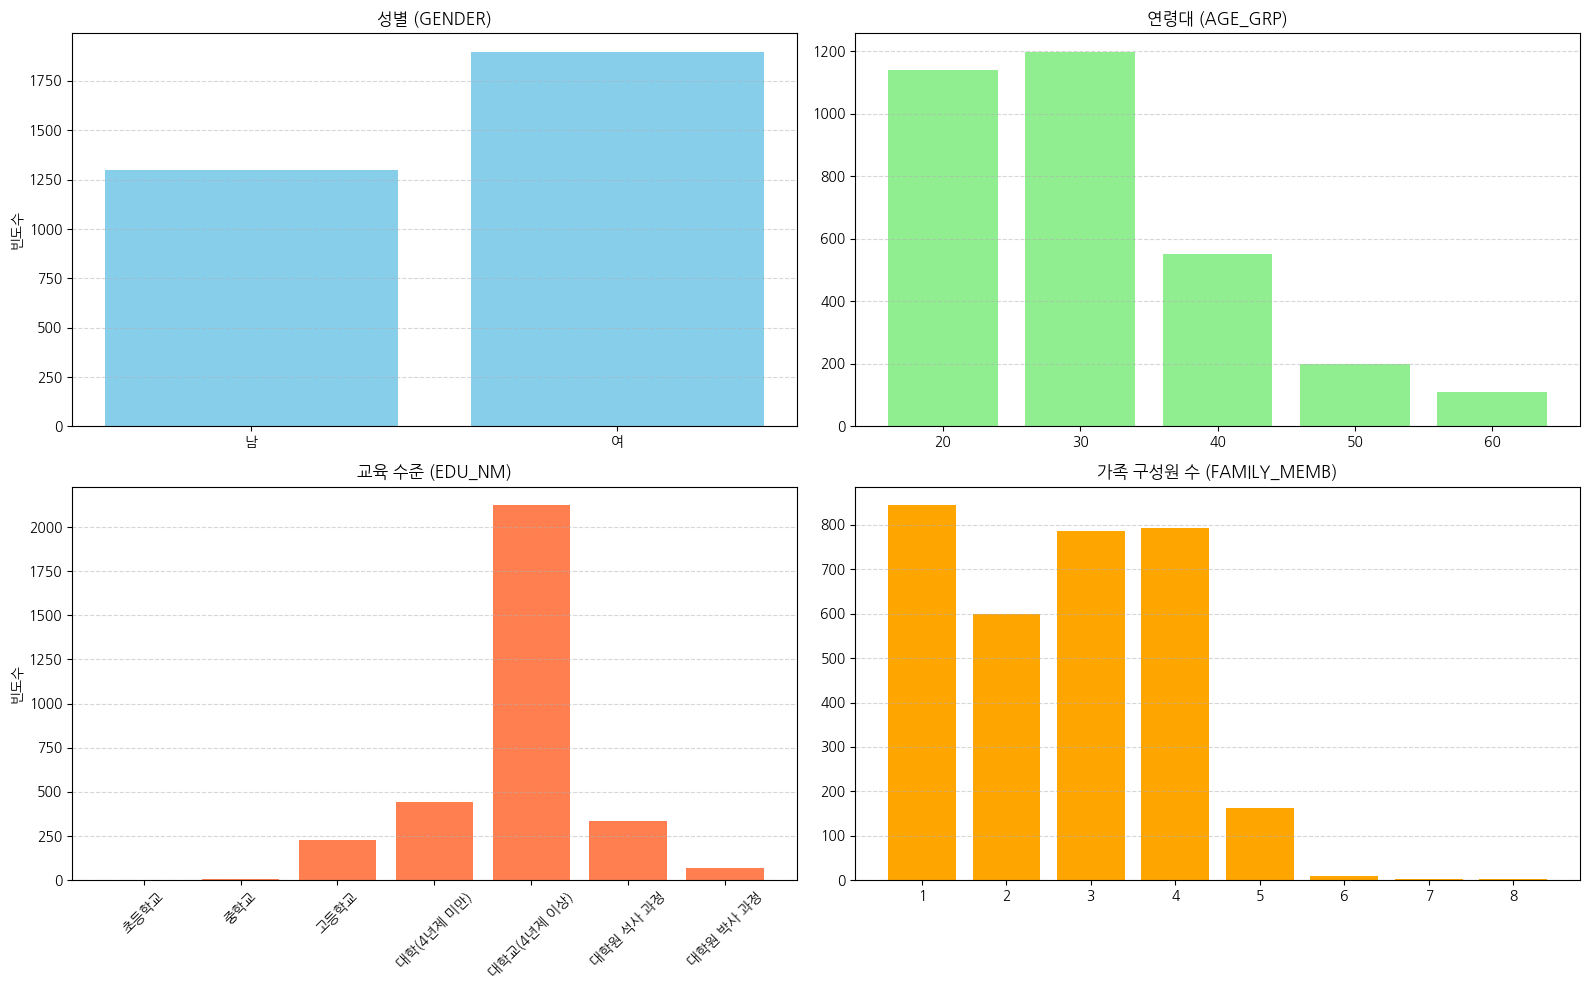

In [19]:
# 각 컬럼별로 라벨 개수 계산 및 정렬
gender_counts = traveler_df['GENDER'].value_counts().sort_index()
age_counts = traveler_df['AGE_GRP'].value_counts().sort_index()
edu_counts = traveler_df['EDU_NM'].value_counts().sort_index()
family_counts = traveler_df['FAMILY_MEMB'].value_counts().sort_index()

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 성별 (GENDER)
axes[0, 0].bar(gender_counts.index.astype(str), gender_counts.values, color='skyblue')
axes[0, 0].set_title('성별 (GENDER)')
axes[0, 0].set_ylabel('빈도수')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

# 연령대 (AGE_GRP)
axes[0, 1].bar(age_counts.index.astype(str), age_counts.values, color='lightgreen')
axes[0, 1].set_title('연령대 (AGE_GRP)')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# 교육 수준 (EDU_NM)
edu_code_map_df = code_df[code_df['cd_a'] == 'EDU']
edu_code_map = dict(zip(edu_code_map_df['cd_b'].astype(int), edu_code_map_df['cd_nm']))
edu_counts.index = edu_counts.index.astype(int)
edu_counts_named = edu_counts.rename(index=edu_code_map)
axes[1, 0].bar(edu_counts_named.index, edu_counts_named.values, color='coral')
axes[1, 0].set_title('교육 수준 (EDU_NM)')
axes[1, 0].set_ylabel('빈도수')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# 가족 구성원 수 (FAMILY_MEMB)
axes[1, 1].bar(family_counts.index.astype(str), family_counts.values, color='orange')
axes[1, 1].set_title('가족 구성원 수 (FAMILY_MEMB)')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

성별을 살펴보면 여성 여행객이 남성 여행객보다 더 많습니다.     
연령대는 20 ~ 30대가 많고, 그 이후로는 연령대가 높을 수록 여행객 수가 적습니다.     
학력은 대학교(4년제 이상)의 여행객이 가장 많고, 가족 구성원 수는 1 ~ 4명 사이가 대부분이네요.

이번에는 여행객의 개인 및 가족 소득 분포를 살펴볼까요?     
`INCOME`과 `HOUSE_INCOME`의 소득 구간 라벨은 다음과 같습니다.

In [20]:
# 소득 구간 정보 코드
code_df.loc[code_df['cd_a'] == 'INC', ['cd_b', 'cd_nm']]

,cd_b,cd_nm
157,1,소득없음
158,2,월평균 100만원 미만
159,3,월평균 100만원 ~ 200만원 미만
160,4,월평균 200만원 ~ 300만원 미만
161,5,월평균 300만원 ~ 400만원 미만
162,6,월평균 400만원 ~ 500만원 미만
163,7,월평균 500만원 ~ 600만원 미만
164,8,월평균 600만원 ~ 700만원 미만
165,9,월평균 700만원 ~ 800만원 미만
166,10,월평균 800만원 ~ 900만원 미만


이제 여행객들의 소득 분포를 시각화해 봅시다.

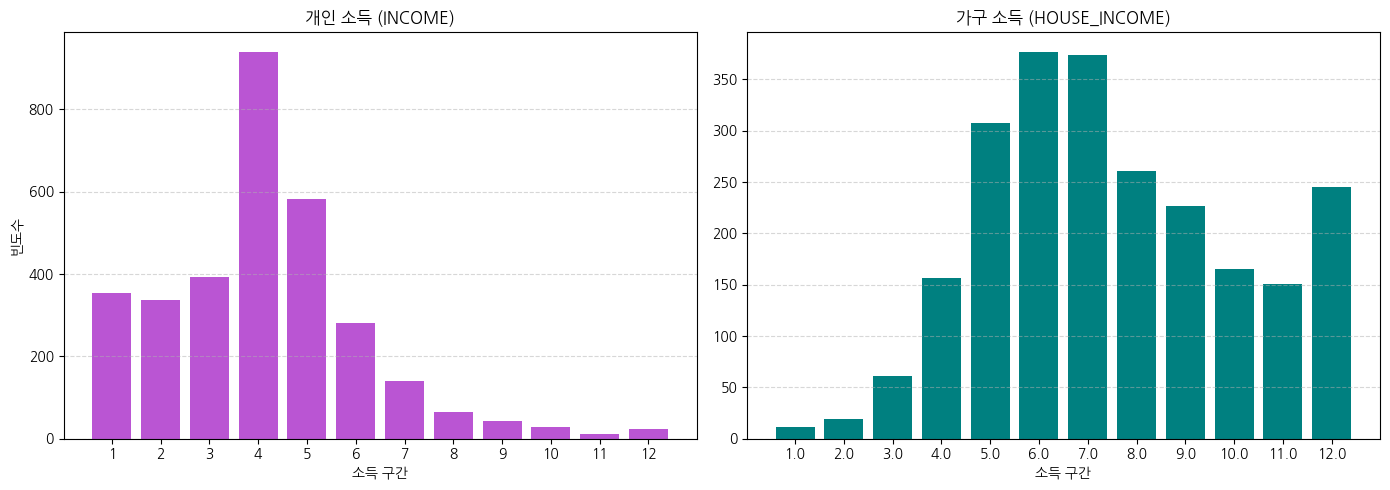

In [21]:
# 소득 구간별 빈도 계산
income_counts = traveler_df['INCOME'].value_counts().sort_index()
house_income_counts = traveler_df['HOUSE_INCOME'].value_counts().sort_index()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 개인 소득 (INCOME)
axes[0].bar(income_counts.index.astype(str), income_counts.values, color='mediumorchid')
axes[0].set_title('개인 소득 (INCOME)')
axes[0].set_ylabel('빈도수')
axes[0].set_xlabel('소득 구간')
axes[0].tick_params(axis='x')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 가구 소득 (HOUSE_INCOME)
axes[1].bar(house_income_counts.index.astype(str), house_income_counts.values, color='teal')
axes[1].set_title('가구 소득 (HOUSE_INCOME)')
axes[1].set_xlabel('소득 구간')
axes[1].tick_params(axis='x')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

개인 소득은 4구간(월평균 200만원 ~ 300만원 미만), 가구 소득은 6구간과 7구간(월평균 400만원 ~ 600만원 미만)인 여행객이 가장 많은 것을 확인할 수 있습니다.

마지막으로 여행 빈도와 여행 동반자 수를 살펴보겠습니다.   
여행 빈도를 나타내는 `TRAVEL_TERM`의 라벨은 다음과 같습니다.

In [22]:
# 여행 빈도 정보 코드
code_df.loc[code_df['cd_a'] == 'TTM', ['cd_b', 'cd_nm']]

,cd_b,cd_nm
169,1,1주일
170,2,한달
171,3,1년
172,4,기타


`TRAVEL_TERM`과 `TRAVEL_COMPANIONS_NUM`의 분포를 시각화해 볼까요?

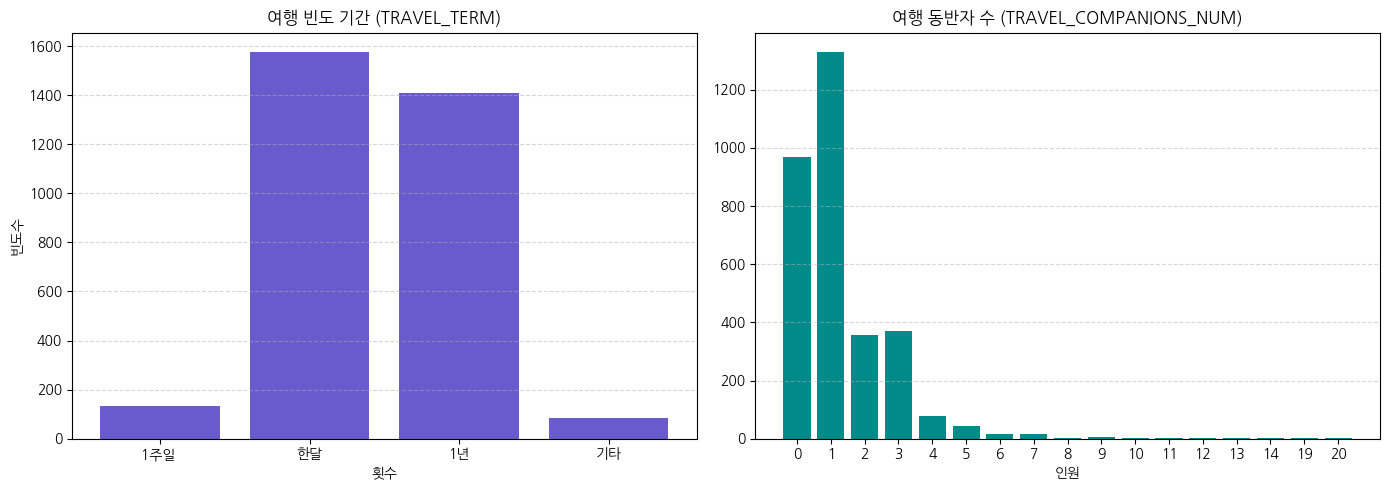

In [23]:
# 여행 빈도 및 동반자 수 빈도 계산
term_counts = traveler_df['TRAVEL_TERM'].value_counts().sort_index()
companions_counts = traveler_df['TRAVEL_COMPANIONS_NUM'].value_counts().sort_index()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 여행 횟수 (TRAVEL_TERM)
ttm_code_map_df = code_df[code_df['cd_a'] == 'TTM']
ttm_code_map = dict(zip(ttm_code_map_df['cd_b'].astype(int), ttm_code_map_df['cd_nm']))
term_counts = traveler_df['TRAVEL_TERM'].value_counts().sort_index()
term_counts.index = term_counts.index.astype(int)
term_counts_named = term_counts.rename(index=ttm_code_map)
axes[0].bar(term_counts_named.index, term_counts_named.values, color='slateblue')
axes[0].set_title('여행 빈도 기간 (TRAVEL_TERM)')
axes[0].set_xlabel('횟수')
axes[0].set_ylabel('빈도수')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 동행자 수 (TRAVEL_COMPANIONS_NUM)
axes[1].bar(companions_counts.index.astype(str), companions_counts.values, color='darkcyan')
axes[1].set_title('여행 동반자 수 (TRAVEL_COMPANIONS_NUM)')
axes[1].set_xlabel('인원')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

여행객들은 주로 한달 또는 1년 주기로 여행을 떠났고, 함께 간 동반자 수는 대부분 0(혼자) ~ 3명 정도입니다.

---

### 2.3. 지출 데이터 분석

이번에는 종속변수인 여행 지출 정보들을 시각화해 보겠습니다.     
활동, 이동, 숙박, 사전 소비 내역 정보를 박스 플롯으로 나타내 볼까요?

/var/folders/6f/l58__vbs153650bznyqlzc580000gn/T/ipykernel_23897/139846433.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(payment_data, labels=labels, showmeans=True)


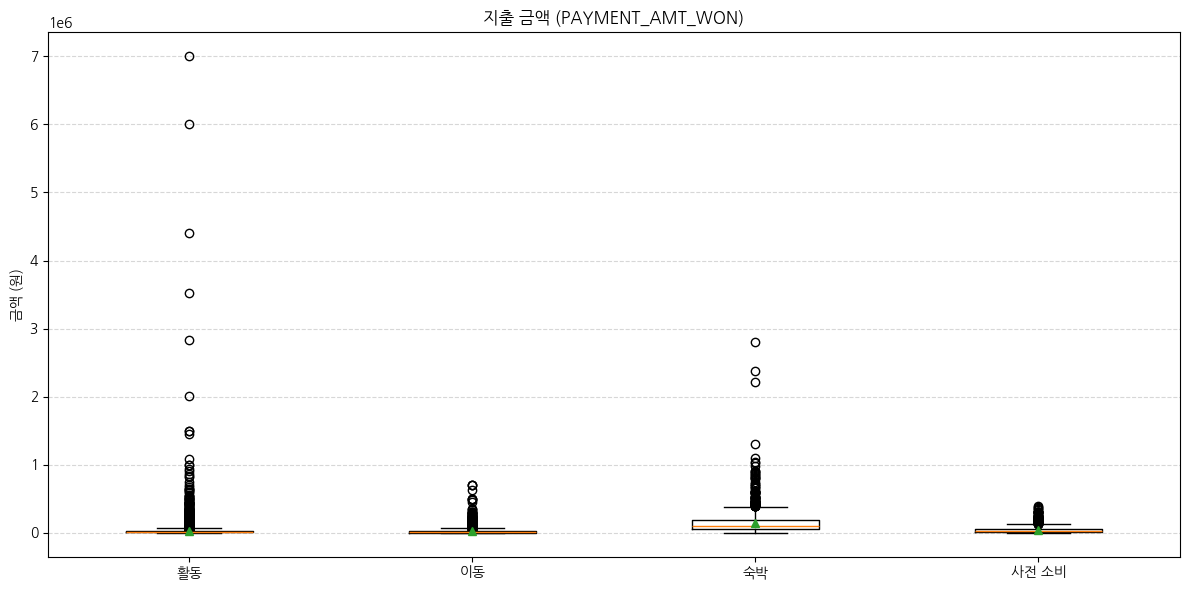

In [24]:
# 각 데이터에서 결제금액 추출
payment_data = [
    activity_df['PAYMENT_AMT_WON'].dropna(),
    move_df['PAYMENT_AMT_WON'].dropna(),
    lodge_df['PAYMENT_AMT_WON'].dropna(),
    pre_expense_df['PAYMENT_AMT_WON'].dropna()
]

# 시각화
labels = ['활동', '이동', '숙박', '사전 소비']
plt.figure(figsize=(12, 6))
plt.boxplot(payment_data, labels=labels, showmeans=True)
plt.title('지출 금액 (PAYMENT_AMT_WON)')
plt.ylabel('금액 (원)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

각 지출 금액에서 이상치(박스 바깥쪽 원)들이 굉장히 많은 것을 볼 수 있습니다.     
이번에는 IQR 기반으로 이상치를 제거 후 다시 시각화를 해보겠습니다.

/var/folders/6f/l58__vbs153650bznyqlzc580000gn/T/ipykernel_23897/2212105876.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(payment_data_cleaned, labels=labels, showmeans=True)


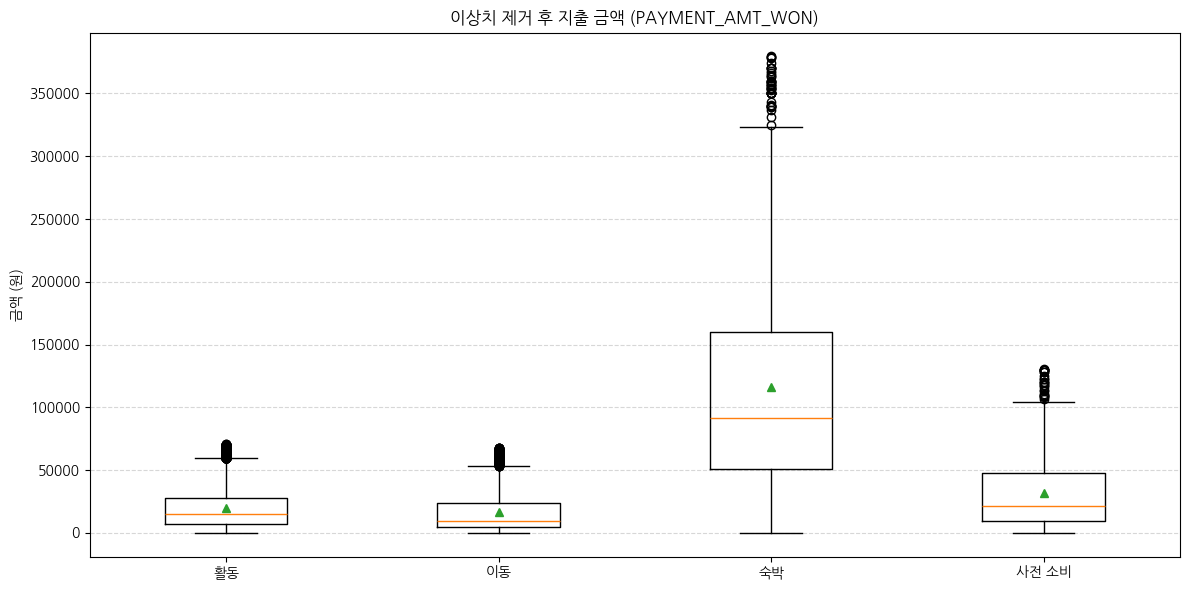

In [25]:
# IQR 기반 이상치 제거 함수 정의
def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series >= lower) & (series <= upper)]

# 이상치 제거 적용
activity_clean = remove_outliers_iqr(activity_df['PAYMENT_AMT_WON'].dropna())
move_clean = remove_outliers_iqr(move_df['PAYMENT_AMT_WON'].dropna())
lodge_clean = remove_outliers_iqr(lodge_df['PAYMENT_AMT_WON'].dropna())
pre_expense_clean = remove_outliers_iqr(pre_expense_df['PAYMENT_AMT_WON'].dropna())
payment_data_cleaned = [activity_clean, move_clean, lodge_clean, pre_expense_clean]

# 시각화
labels = ['활동', '이동', '숙박', '사전 소비']
plt.figure(figsize=(12, 6))
plt.boxplot(payment_data_cleaned, labels=labels, showmeans=True)
plt.title('이상치 제거 후 지출 금액 (PAYMENT_AMT_WON)')
plt.ylabel('금액 (원)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


이제 이상치들이 일부 제거되어 박스 플롯의 가독성이 높아졌습니다.      
박스는 중간 50% 데이터를 나타내고, 주황색 선은 중앙값을, 초록색 삼각형은 평균값을 나타냅니다.    
여행 지출 금액에서 숙박 비용의 평균이 가장 높고, 또 적게 지출하는 사람과 많이 지출하는 사람의 차이도 가장 큰 것을 알 수 있습니다.

---

## 3. 데이터 전처리

이번 챕터에서는 머신러닝 목적에 적합한 형태로 데이터를 전처리하는 실습을 진행하겠습니다.    
전처리 계획은 다음과 같습니다.     

> 독립변수
> - 여행 데이터와 여행객 데이터에서 독립변수로 사용할 컬럼 선택 및 전처리 (인코딩 등)
> - 여행객 ID를 기준으로 여행 데이터와 여행객 데이터 병합 
>
> 종속변수
> - 여행 ID를 기준으로 활동, 이동, 숙박, 사전 소비 데이터 합산
> - 이상치 제거

### 3.1. 여행 데이터 전처리

여행 데이터에서는 여행 기간, 여행 목적, 여행 미션 컬럼을 사용할 예정입니다.   
먼저 `TRAVEL_START_YMD`와 `TRAVEL_END_YMD`을 통해 여행 기간(일)을 계산하고 새로운 `TRAVEL_DURATION_DAYS` 컬럼을 생성합니다.

In [26]:
# 여행 데이터 복사
travel_df_p = travel_df.copy()

# 여행 기간
travel_df_p['TRAVEL_START_YMD'] = pd.to_datetime(travel_df_p['TRAVEL_START_YMD'])
travel_df_p['TRAVEL_END_YMD'] = pd.to_datetime(travel_df_p['TRAVEL_END_YMD'])
travel_df_p['TRAVEL_DURATION_DAYS'] = (travel_df_p['TRAVEL_END_YMD'] - travel_df_p['TRAVEL_START_YMD']).dt.days + 1

이어서 여행 목적과 미션을 인코딩해 보겠습니다.     
`TRAVEL_PURPOSE`와 `TRAVEL_MISSION`에는 여러 개의 라벨이 동시에 존재합니다. 예를 들어, 한 사람의 여행 목적이 1번(휴식), 2번(관광), 22번(업무) 모두일 수 있습니다.     
이를 머신러닝에서 다루기 쉽게 각 라벨마다 별도 열을 만들고, 해당 라벨이 포함되어 있으면 1, 없으면 0으로 표시하도록 인코딩해 보겠습니다.

인코딩 예시:

| TRAVEL_MISSION   | TRAVEL_MISSION_1 | TRAVEL_MISSION_2 | ... | TRAVEL_MISSION_22 |
|---------------------|------------------|------------------|-----|-------------------|
| 1;2;22;   |        1         |        1         | ... |         1         |
| 5:22;24;  |        0         |        0         | ... |         1         |


In [27]:
# 여행 목적, 미션
# Multi-label Binary Encoding
def binary_labeling(df, column, prefix, label_range=28):
    # 세미콜론 기준으로 분리하고 set으로 변환
    label_sets = df[column].str.strip(';').str.split(';').apply(lambda x: set(x))
    # 1부터 28까지 순회하면서 열 생성
    for i in range(1, label_range + 1):
        col_name = f'{prefix}_{i}'
        df[col_name] = label_sets.apply(lambda x: 1 if str(i) in x else 0)
    return df

travel_df_p = binary_labeling(travel_df_p, 'TRAVEL_PURPOSE', 'TRAVEL_PURPOSE')
travel_df_p = binary_labeling(travel_df_p, 'TRAVEL_MISSION', 'TRAVEL_MISSION')

마지막으로 불필요한 컬럼을 삭제하고, 전처리된 여행 데이터를 확인해 볼까요?

In [28]:
# 불필요한 컬럼 삭제
travel_df_p.drop(columns=[
    'TRAVEL_NM', 
    'TRAVEL_PERSONA', 
    'TRAVEL_START_YMD', 
    'TRAVEL_END_YMD', 
    'MVMN_NM', 
    'TRAVEL_PURPOSE',
    'TRAVEL_MISSION',
    'TRAVEL_MISSION_CHECK'
    ],
    inplace=True)

travel_df_p.head()

,TRAVEL_ID,TRAVELER_ID,TRAVEL_DURATION_DAYS,TRAVEL_PURPOSE_1,TRAVEL_PURPOSE_2,TRAVEL_PURPOSE_3,TRAVEL_PURPOSE_4,TRAVEL_PURPOSE_5,TRAVEL_PURPOSE_6,TRAVEL_PURPOSE_7,...,TRAVEL_MISSION_19,TRAVEL_MISSION_20,TRAVEL_MISSION_21,TRAVEL_MISSION_22,TRAVEL_MISSION_23,TRAVEL_MISSION_24,TRAVEL_MISSION_25,TRAVEL_MISSION_26,TRAVEL_MISSION_27,TRAVEL_MISSION_28
0,a_a014262,a014262,2,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,a_a006728,a006728,2,0,0,0,0,1,0,0,...,0,0,1,1,0,1,0,1,1,0
2,a_a015745,a015745,4,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,a_a010544,a010544,2,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,1,0,0
4,a_a012058,a012058,2,1,0,0,1,0,0,0,...,0,0,1,1,0,0,0,1,0,0


---

### 3.2. 여행객 데이터 전처리 

여행객 데이터에서는 성별, 연령대, 학력, 가족 구성원 수, 직업, 개인 및 가구 소득, 여행 빈도, 여행 동반자 수, 여행 스타일, 여행 동기 정보를 사용할 예정입니다.     
먼저 `GENDER` 정보를 인코딩해 줍니다.

In [29]:
traveler_df_p = traveler_df.copy()

le = LabelEncoder()

# 성별
traveler_df_p['GENDER'] = le.fit_transform(traveler_df_p['GENDER'])

앞서 여행 목적과 미션을 인코딩한 것처럼, 여행 동기도 각 라벨마다 별도 열을 만들어 해당 라벨이 포함되어 있으면 1, 없으면 0으로 표시하도록 인코딩해 보겠습니다.

In [30]:
# 여행 동기
traveler_df_p['TRAVEL_MOTIVES'] = traveler_df_p[['TRAVEL_MOTIVE_1', 'TRAVEL_MOTIVE_2', 'TRAVEL_MOTIVE_3']].values.tolist()
traveler_df_p.drop(columns=['TRAVEL_MOTIVE_1', 'TRAVEL_MOTIVE_2','TRAVEL_MOTIVE_3'], inplace=True)

def binary_labeling(df, column, prefix, label_range=10):
    for i in range(1, label_range + 1):
        col_name = f'{prefix}_{i}'
        df[col_name] = df[column].apply(lambda x: 1 if i in x else 0)
    return df

traveler_df_p = binary_labeling(traveler_df_p, 'TRAVEL_MOTIVES', 'TRAVEL_MOTIVE')

또한 가구 소득의 결측값이 있는 경우 평균값으로 대체하여 채우도록 합니다.

In [31]:
# 가구 소득
mean_income = traveler_df_p['HOUSE_INCOME'].mean()
traveler_df_p['HOUSE_INCOME'].fillna(mean_income, inplace=True)

/var/folders/6f/l58__vbs153650bznyqlzc580000gn/T/ipykernel_23897/2290487053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  traveler_df_p['HOUSE_INCOME'].fillna(mean_income, inplace=True)


마지막으로 불필요한 컬럼을 삭제하고, 전처리된 여행객 데이터를 살펴볼까요?

In [32]:
# 불필요한 컬럼 삭제
traveler_df_p.drop(columns=[
    'JOB_ETC',
    'TRAVEL_LIKE_SIDO_1',
    'TRAVEL_LIKE_SGG_1',
    'TRAVEL_LIKE_SIDO_2',
    'TRAVEL_LIKE_SGG_2',
    'TRAVEL_LIKE_SIDO_3',
    'TRAVEL_LIKE_SGG_3',
    'TRAVEL_STATUS_RESIDENCE',
    'TRAVEL_STATUS_DESTINATION',
    'TRAVEL_STATUS_ACCOMPANY',
    'TRAVEL_STATUS_YMD',
    'TRAVEL_MOTIVES',
    'RESIDENCE_SGG_CD',
    'EDU_FNSH_SE',
    'MARR_STTS',
    'TRAVEL_NUM'
    ],
    inplace=True)

traveler_df_p.dropna(inplace=True)
traveler_df_p.head()

,TRAVELER_ID,GENDER,AGE_GRP,EDU_NM,FAMILY_MEMB,JOB_NM,INCOME,HOUSE_INCOME,TRAVEL_TERM,TRAVEL_STYL_1,...,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_MOTIVE_4,TRAVEL_MOTIVE_5,TRAVEL_MOTIVE_6,TRAVEL_MOTIVE_7,TRAVEL_MOTIVE_8,TRAVEL_MOTIVE_9,TRAVEL_MOTIVE_10
0,b015583,1,20,6,5,3.0,3,7.0,2,1,...,1,0,0,0,0,0,0,0,0,0
1,a001105,0,30,6,2,3.0,4,6.0,3,6,...,0,0,1,0,0,0,0,0,0,0
3,a017690,1,30,6,3,3.0,5,7.0,3,2,...,1,1,1,0,0,0,0,0,0,0
4,c006666,1,30,6,3,13.0,3,7.0,2,3,...,1,1,0,0,0,0,1,0,0,0
5,a007192,0,20,7,4,2.0,7,12.0,2,4,...,0,1,0,0,0,1,0,1,0,0


---

### 3.3. 지출 데이터 전처리

활동, 이동, 숙박, 사전 소비 데이터에서 지출 금액을 나타내는 `PAYMENT_AMT_WON`만 추출합니다.

In [33]:
# 활동 지출 데이터
activity_df_p = activity_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']]
activity_df_p = activity_df_p.rename(columns={'PAYMENT_AMT_WON': 'ACT_WON'})
activity_df_p.head()

,TRAVEL_ID,ACT_WON
0,a_a004739,22000.0
1,a_a002397,33000.0
2,a_a017904,31400.0
3,a_a018111,48000.0
4,a_a005012,10000.0


In [34]:
# 이동 지출 데이터
move_df_p = move_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']]
move_df_p = move_df_p.rename(columns={'PAYMENT_AMT_WON': 'MOVE_WON'})
move_df_p.head()

,TRAVEL_ID,MOVE_WON
0,a_a000279,70000
1,a_a004250,50000
2,a_a003984,0
3,a_a000336,11000
4,a_a014619,10000


In [35]:
# 숙박 지출 데이터
lodge_df_p = lodge_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']]
lodge_df_p = lodge_df_p.rename(columns={'PAYMENT_AMT_WON': 'LODGE_WON'})
lodge_df_p.head()

,TRAVEL_ID,LODGE_WON
0,a_a000290,160000
1,a_a000805,100000
2,a_a012504,36000
3,a_a001356,102460
4,a_a003139,340000


In [36]:
# 사전 소비 지출 데이터
pre_expense_df_p = pre_expense_df[['TRAVEL_ID', 'PAYMENT_AMT_WON']]
pre_expense_df_p = pre_expense_df_p.rename(columns={'PAYMENT_AMT_WON': 'PRE_WON'})
pre_expense_df_p.head()

,TRAVEL_ID,PRE_WON
0,a_a007376,10000
1,a_a000122,6800
2,a_a003807,81000
3,a_a009440,69800
4,a_a017885,39990


---

### 3.4. 데이터 병합

앞서 전처리한 데이터들을 최종적으로 병합해보도록 하겠습니다.     
먼저 독립변수로 사용할 여행 및 여행객 데이터를 `TRAVELER_ID` 기준으로 병합합니다.

In [37]:
merged_df = pd.merge(travel_df_p, traveler_df_p, on='TRAVELER_ID', how='inner') 
merged_df

,TRAVEL_ID,TRAVELER_ID,TRAVEL_DURATION_DAYS,TRAVEL_PURPOSE_1,TRAVEL_PURPOSE_2,TRAVEL_PURPOSE_3,TRAVEL_PURPOSE_4,TRAVEL_PURPOSE_5,TRAVEL_PURPOSE_6,TRAVEL_PURPOSE_7,...,TRAVEL_MOTIVE_1,TRAVEL_MOTIVE_2,TRAVEL_MOTIVE_3,TRAVEL_MOTIVE_4,TRAVEL_MOTIVE_5,TRAVEL_MOTIVE_6,TRAVEL_MOTIVE_7,TRAVEL_MOTIVE_8,TRAVEL_MOTIVE_9,TRAVEL_MOTIVE_10
0,a_a014262,a014262,2,1,1,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
1,a_a006728,a006728,2,0,0,0,0,1,0,0,...,1,0,1,0,0,1,0,0,0,0
2,a_a015745,a015745,4,1,1,0,0,0,1,0,...,0,1,0,0,0,0,1,1,0,0
3,a_a010544,a010544,2,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,a_a012058,a012058,2,1,0,0,1,0,0,0,...,1,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2457,a_a008457,a008457,3,1,0,0,1,0,1,0,...,0,1,0,1,0,1,0,0,0,0
2458,a_a007638,a007638,2,1,0,0,0,0,0,0,...,0,1,1,0,1,0,0,0,0,0
2459,a_a002111,a002111,3,0,0,0,1,0,1,0,...,1,0,1,0,0,0,1,0,0,0
2460,a_a007634,a007634,2,0,0,0,1,0,0,0,...,1,0,1,1,0,0,0,0,0,0


다음으로 종속변수로 사용할 지출 데이터들을 `TRAVEL_ID` 기준으로 병합합니다.    
이때 `TRAVELER_ID`별로 그룹화하여 활동, 이동, 숙박, 사전 소비 지출들을 전부 합산하고, 지출 금액 기준 이상치들을 제거합니다. 

In [38]:
# 지출 데이터 병합
merged_df = pd.merge(merged_df, activity_df_p, on='TRAVEL_ID', how='left')
merged_df = pd.merge(merged_df, move_df_p, on='TRAVEL_ID', how='left') 
merged_df = pd.merge(merged_df, lodge_df_p, on='TRAVEL_ID', how='left') 
merged_df = pd.merge(merged_df, pre_expense_df_p, on='TRAVEL_ID', how='left') 

# 지출 금액 합산
won_columns = [col for col in merged_df.columns if col.endswith('WON')]
merged_df['WON_SUM'] = merged_df[won_columns].sum(axis=1)
merged_df.drop(columns=won_columns, inplace=True)
merged_df['WON_SUM'] = merged_df.groupby('TRAVELER_ID')['WON_SUM'].transform('sum')
merged_df.drop_duplicates(subset='TRAVELER_ID', keep='first', inplace=True)
merged_df.drop(columns=['TRAVEL_ID'], inplace=True)

# 지출 금액 이상치 제거
merged_df = merged_df[merged_df['WON_SUM'] > 0]
Q1 = merged_df['WON_SUM'].quantile(0.25)
Q3 = merged_df['WON_SUM'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
merged_df = merged_df[(merged_df['WON_SUM'] >= lower_bound) & (merged_df['WON_SUM'] <= upper_bound)]
merged_df.reset_index(drop=True, inplace=True)

최종 데이터의 형태를 살펴볼까요?

In [39]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 86 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   TRAVELER_ID            2128 non-null   object 
 1   TRAVEL_DURATION_DAYS   2128 non-null   int64  
 2   TRAVEL_PURPOSE_1       2128 non-null   int64  
 3   TRAVEL_PURPOSE_2       2128 non-null   int64  
 4   TRAVEL_PURPOSE_3       2128 non-null   int64  
 5   TRAVEL_PURPOSE_4       2128 non-null   int64  
 6   TRAVEL_PURPOSE_5       2128 non-null   int64  
 7   TRAVEL_PURPOSE_6       2128 non-null   int64  
 8   TRAVEL_PURPOSE_7       2128 non-null   int64  
 9   TRAVEL_PURPOSE_8       2128 non-null   int64  
 10  TRAVEL_PURPOSE_9       2128 non-null   int64  
 11  TRAVEL_PURPOSE_10      2128 non-null   int64  
 12  TRAVEL_PURPOSE_11      2128 non-null   int64  
 13  TRAVEL_PURPOSE_12      2128 non-null   int64  
 14  TRAVEL_PURPOSE_13      2128 non-null   int64  
 15  TRAV

총 2128개의 행과 84개의 독립변수, 1개의 종속변수(`WON_SUM`)로 구성되어 있습니다.     
이제 이 데이터를 csv 파일로 저장해줍니다.

In [40]:
# 데이터 저장
merged_df.to_csv('data/dataset.csv', index=False, encoding='utf-8-sig')

---

## 4. 여행 지출 금액 회귀 모델

이번 챕터에서는 여행객 정보를 바탕으로 여행 지출 금액을 예측하는 회귀 모델을 실습해 보겠습니다.

### 4.1. LinearRegression

먼저, 가장 기본적인 선형회귀를 진행해보겠습니다.     
하나의 독립변수 `TRAVEL_DURATION_DAYS`만 선택하여 단순선형회귀 모델을 만들어 볼까요?     
앞서 전처리를 완료했던 데이터를 불러오고, 독립변수와 종속변수를 골라 정규화를 진행합니다.

>📌 `StandardScaler`는 입력 데이터의 값들을 평균이 0, 표준편차가 1이 되도록 변환하여, 머신러닝 모델이 특정 크기의 변수에 치우치지 않고 모든 변수의 영향을 균등하게 고려할 수 있도록 합니다.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv('data/dataset.csv', encoding='utf-8-sig')

# 독립변수와 종속변수 선택
X = df[['TRAVEL_DURATION_DAYS']]  # 하나의 독립변수
y = df['WON_SUM']

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

여행 기간(일)을 기반으로 여행 지출 금액을 예측하는 단순선형회귀 모델을 학습해 봅시다.     
평가 지표는 다음과 같습니다. 

> - `RMSE (Root Mean Squared Error)`: 예측값과 실제값의 차이를 제곱 평균한 뒤 다시 제곱근을 취한 값으로, 예측 오차의 평균적인 크기를 나타내며 **값이 낮을수록** 좋습니다.
>
> - `MAPE (Mean Absolute Percentage Error)`: 예측값과 실제값의 차이를 실제값으로 나눈 비율의 평균으로, 퍼센트 단위로 예측 오차를 나타내며 **값이 낮을수록** 모델의 정확도가 높습니다.
>
> - `R² (R-squared)`: 모델이 실제 데이터를 얼마나 잘 설명하는지를 0부터 1 사이의 값으로 나타내며, 값이 **1에 가까울수록** 모델의 예측력이 좋고, 0에 가까울수록 나쁩니다.

In [51]:
from sklearn.linear_model import LinearRegression

# 모델 정의 및 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 학습 데이터 예측 및 평가
y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 테스트 데이터 예측 및 평가
y_pred = lr.predict(X_test)
r2_test = r2_score(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Linear Regression")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")

Linear Regression

Train RMSE: 365138.91801413544
Train MAPE: 4.132559412382668
Train R^2: 0.2622754414189079

Test RMSE: 350462.0170506254
Test MAPE: 3.633360980495423
Test R^2: 0.27352301458380657


Test 결과들을 보면 RMSE는 약 350000으로 높고, R²는 0.27 정도로 모델의 설명력이 낮은 것을 확인할 수 있습니다.     
그럼 하나의 독립변수가 아니라 여러 독립변수를 입력하는 다중회귀 모델은 성능이 더 나아질까요?     
이번에는 다음과 같이 다중회귀 모델을 학습하고 결과를 비교해 봅시다.

In [52]:
# 독립변수와 종속변수 선택
X = df.drop(columns=['TRAVELER_ID', 'WON_SUM'])  # 여러 독립변수
y = df['WON_SUM']

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# 모델 정의 및 학습
lr = LinearRegression()
lr.fit(X_train, y_train)

# 학습 데이터 예측 및 평가
y_pred_train = lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 테스트 데이터 예측 및 평가
y_pred = lr.predict(X_test)
r2_test = r2_score(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Linear Regression")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")

Linear Regression

Train RMSE: 345074.50460535235
Train MAPE: 3.578275115602326
Train R^2: 0.34112392330072416

Test RMSE: 343649.05531478935
Test MAPE: 3.13704505419359
Test R^2: 0.30149381344491955


위의 단순선형회귀 모델의 Test 결과와 비교해보면, RMSE와 MAPE가 줄고 R²는 상승한 것을 볼 수 있습니다.     
그런데 여기서 잠깐, 다중회귀에서는 독립변수(설명변수)의 수가 많아질수록 R² 값이 인위적으로 높아지는 경향이 있는데요.    
이는 모델에 의미 없는 변수까지 추가해도 R²가 증가할 수 있다는 뜻으로, 모델의 진짜 예측력을 과대평가할 위험이 있습니다.     
그래서 수정된 결정계수(Adjusted R²)를 추가적으로 확인해야 합니다.

> `Adjusted R² (수정된 결정계수)`: 모델에 포함된 독립변수의 수를 고려하여, 불필요한 변수 추가로 인한 R² 값의 인위적 상승을 보정해 실제 모델 설명력을 더 정확하게 나타내는 지표입니다.

In [54]:
# 수정된 R^2 계산 함수
def adjusted_r2(r2, n, p):
    """
    r2 : 일반 결정계수 (R²)
    n  : 관측치의 개수 (샘플 수)
    p  : 독립변수의 개수
    """
    return 1 - (1 - r2) * ((n - 1) / (n - p - 1))

n_train, p_train = X_train.shape
n_test, p_test = X_test.shape

adj_r2_train = adjusted_r2(r2_score(y_train, y_pred_train), n_train, p_train)
adj_r2_test = adjusted_r2(r2_score(y_test, y_pred), n_test, p_test)
print(f"Train Adjusted R^2: {adj_r2_train}")
print(f"Test Adjusted R^2: {adj_r2_test}")

Train Adjusted R^2: 0.3068965946410215
Test Adjusted R^2: 0.12942777335510502


R²는 약 0.30이지만 Adjusted R²는 약 0.13입니다.    
즉 불필요한 변수들이 추가되어 모델의 예측력이 과대평가된 것을 알 수 있습니다.

이번엔 회귀 계수도 살펴볼까요?    
회귀 계수는 독립변수 1단위 변화가 종속변수에 미치는 영향을 의미합니다.

In [64]:
# 회귀 계수 확인
coefficients = lr.coef_
feature_names = X.columns  

feature_coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values(by='coefficient', ascending=False)

feature_coefficients

,feature,coefficient
8,TRAVEL_PURPOSE_8,327629.605355
7,TRAVEL_PURPOSE_7,262696.310970
30,TRAVEL_MISSION_2,251722.286011
39,TRAVEL_MISSION_11,238444.513301
3,TRAVEL_PURPOSE_3,226931.827119
...,...,...
31,TRAVEL_MISSION_3,-225321.208704
11,TRAVEL_PURPOSE_11,-244139.511457
2,TRAVEL_PURPOSE_2,-250906.667787
35,TRAVEL_MISSION_7,-253325.229435


`TRAVEL_PURPOSE_8`이 '캠핑 여부'를 나타내는 더미 변수(0 = 캠핑 아님, 1 = 캠핑)이므로,     
"다른 조건이 모두 같을 때, 캠핑일 경우 여행 지출이 평균적으로 약 327,630원 더 많아진다"라고 회귀 게수를 해석해볼 수 있습니다.

독립변수의 수가 너무 많아서 R² 등의 성능에 악영향이 있는 것 같은데요.    
이제 여러 독립변수들 중 중요한 독립변수들만 선택하여 모델을 새롭게 만들어 볼까요?    
앞서 학습했던 모델의 feature 중요도를 기반으로 평균 이상의 중요도를 가진 feature만 선택하겠습니다.

In [66]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(lr, prefit=True, threshold='mean')  # 계수의 절댓값이 평균보다 큰 경우 선택
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# 선택된 feature 수
print(X_train_selected.shape[1])
print(X_test_selected.shape[1])

25
25


이렇게 선택된 25개의 feature로 다시 다중회귀 모델을 학습해 봅시다.

In [67]:
# 모델 정의 및 학습
lr = LinearRegression()
lr.fit(X_train_selected, y_train)

# 학습 데이터 예측 및 평가
y_pred_train = lr.predict(X_train_selected)
r2_train = r2_score(y_train, y_pred_train)
adj_r2_train = adjusted_r2(r2_train, X_train_selected.shape[0], X_train_selected.shape[1])
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 테스트 데이터 예측 및 평가
y_pred = lr.predict(X_test_selected)
r2_test = r2_score(y_test, y_pred)
adj_r2_test = adjusted_r2(r2_test, X_test_selected.shape[0], X_test_selected.shape[1])
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Linear Regression")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print(f"Train Adjusted R^2: {adj_r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")
print(f"Test Adjusted R^2: {adj_r2_test}")

Linear Regression

Train RMSE: 359047.94457820914
Train MAPE: 3.9950388454597734
Train R^2: 0.2866824941860191
Train Adjusted R^2: 0.27604231659332845

Test RMSE: 350134.4320255549
Test MAPE: 3.560492179011898
Test R^2: 0.2748804898352454
Test Adjusted R^2: 0.22956052044994824


앞선 모델과 비교해보면, feature 수에 대한 패널티가 감소하여 Adjusted R²는 0.22로 상승했지만, RMSE와 MAPE 등 다른 지표에서는 성능이 오히려 저하된 것을 볼 수 있네요.

---

### 4.2. RandomForestRegressor

이번엔 `RandomForestRegressor`를 통해 다중회귀 모델을 학습해 봅시다.     
이때 독립변수는 feature selection을 거치지 않은 상태로 전부 입력합니다.

> 📌 `RandomForestRegressor`는 여러 개의 의사결정트리를 조합해 예측 정확도를 높이고 과적합을 줄이는 앙상블 회귀 모델입니다.

In [76]:
from sklearn.ensemble import RandomForestRegressor

# 모델 정의 및 학습
rf_lr = RandomForestRegressor(
    n_estimators=2000,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_lr.fit(X_train, y_train)

# 학습 데이터 예측 및 평가
y_pred_train = rf_lr.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
adj_r2_train = adjusted_r2(r2_train, X_train.shape[0], X_train.shape[1])

# 테스트 데이터 예측 및 평가
y_pred = rf_lr.predict(X_test)
r2_test = r2_score(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)
adj_r2_test = adjusted_r2(r2_test, X_test.shape[0], X_test.shape[1])

print("Random Forest Regressor")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print(f"Train Adjusted R^2: {adj_r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")
print(f"Test Adjusted R^2: {adj_r2_test}")

Random Forest Regressor

Train RMSE: 290379.5933535971
Train MAPE: 3.3578839503344255
Train R^2: 0.5334371254801742
Train Adjusted R^2: 0.5092000930375858

Test RMSE: 336817.15211441723
Test MAPE: 3.6610956087208386
Test R^2: 0.32899099714802105
Test Adjusted R^2: 0.163698456856038


Train과 Test를 비교해보면 모든 지표에서 현재 모델이 다소 과적합되었다는 것을 알 수 있습니다.     
이번에도 feature selection을 통해 중요한 변수들만 선택하는 것이 좋겠습니다.      
먼저 현재 모델의 feature 중요도를 확인해 봅시다.

In [77]:
# 중요도 확인
importances = rf_lr.feature_importances_
feature_names = X.columns

feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importances

,feature,importance
0,TRAVEL_DURATION_DAYS,0.343280
73,TRAVEL_COMPANIONS_NUM,0.040187
66,TRAVEL_STYL_2,0.033612
23,TRAVEL_PURPOSE_23,0.031717
51,TRAVEL_MISSION_23,0.027159
...,...,...
20,TRAVEL_PURPOSE_20,0.000000
46,TRAVEL_MISSION_18,0.000000
45,TRAVEL_MISSION_17,0.000000
44,TRAVEL_MISSION_16,0.000000


이제 중요한 feature만 선택합니다.

In [78]:
selector = SelectFromModel(rf_lr, prefit=True, threshold='mean') 
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# 선택된 feature 수
print(X_train_selected.shape[1])
print(X_test_selected.shape[1])

18
18


이렇게 선택된 18개의 feature로 새롭게 모델을 학습해 봅시다.

---

### <span style="font-size:24px">[TODO] RandomForestRegressor 학습</span>


- 목표: RandomForestRegressor 모델 학습 및 평가
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: feature selection을 거친 모델을 학습 및 평가하고 각 평가지표(RMSE, MAPE, Adjusted R²) 중 **하나라도 성능 개선이 이루어진 경우** 통과
    - Test RMSE: 336817 이하인 경우 통과
    - Test MAPE: 3.661 이하인 경우 통과
    - Test Adjusted R^2: 0.163 이상인 경우 통과

In [ ]:
# 모델 정의 및 학습
rf_lr = RandomForestRegressor(
    #################################### 
    # [TODO] 모델 학습 파라미터를 작성하세요.
    # 힌트: 위에서 사용한 파라미터를 그대로 사용해도 무방하고,
    #      여러 파라미터를 실험해보며 최적의 파라미터를 찾아보는 것도 좋은 방법입니다.
    n_estimators=2000,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
    ###################################
)


#################################### 
# [TODO] 모델 학습 코드를 작성하세요.
# 힌트: 독립변수는 X_train_selected, 종속변수는 y_train입니다. 
rf_lr.fit(X_train_selected, y_train)
####################################


#################################### 
# [TODO] 모델 평가 코드를 작성하세요.
# 힌트: 아래 None으로 선언된 임시 변수들을 활용하여 테스트 셋에 대한 모델 예측 값과 평가 결과를 저장하세요. 
#      테스트 독립변수는 X_test_selected, 종속변수는 y_test입니다.
#      *해당 변수들은 채점 기준이 되는 변수들이므로 변수명을 절대 변경하지 마세요!*
#      
y_pred_todo1 = rf_lr.predict(X_test_selected)
rmse_test_todo1 = np.sqrt(mean_squared_error(y_test, y_pred_todo1))
mape_test_todo1 = mean_absolute_percentage_error(y_test, y_pred_todo1)
r2_test_todo1 = r2_score(y_test, y_pred_todo1)
adj_r2_test_todo1 = adjusted_r2(r2_test_todo1, X_test_selected.shape[0], X_test_selected.shape[1])
####################################

print("Random Forest Regressor")
print()
print(f"Test RMSE: {rmse_test_todo1}")
print(f"Test MAPE: {mape_test_todo1}")
print(f"Test Adjusted R^2: {adj_r2_test_todo1}")

---

### 4.3. CatBoostRegressor

이번에는 `CatBoostRegressor` 모델을 사용해 봅시다.

> 📌 `CatBoostRegressor`는 범주형 변수 처리를 자동으로 최적화하고 안정적인 일반화를 제공하는 gradient boosting 기반의 앙상블 회귀 모델입니다.

In [87]:
from catboost import CatBoostRegressor, Pool

# 모델 정의 및 학습
cat_lr = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.01,
    depth=10,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=0
)
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)
cat_lr.fit(train_pool)

# 학습 데이터 예측 및 평가
y_pred_train = cat_lr.predict(train_pool)
r2_train = r2_score(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
adj_r2_train = adjusted_r2(r2_train, X_train.shape[0], X_train.shape[1])

# 테스트 데이터 예측 및 평가
y_pred = cat_lr.predict(test_pool)
r2_test = r2_score(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)
adj_r2_test = adjusted_r2(r2_test, X_test.shape[0], X_test.shape[1])

print("CatBoost Regressor")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print(f"Train Adjusted R^2: {adj_r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")
print(f"Test Adjusted R^2: {adj_r2_test}")

CatBoost Regressor

Train RMSE: 83512.90001755343
Train MAPE: 0.9318456596939184
Train R^2: 0.9614090808567152
Train Adjusted R^2: 0.9594043577843367

Test RMSE: 326483.0956884041
Test MAPE: 3.0269467371048258
Test R^2: 0.3695344690438892
Test Adjusted R^2: 0.21422917696085897


Train Adjusted R²는 0.95로 매우 높지만 Test Adjusted R²는 0.21로 다소 낮고, RMSE의 경우에도 Train과 Test의 차이가 매우 큽니다.     
즉 현재 모델은 과적합이 되어 있으므로, feature selection을 통해 중요한 변수만을 골라 새롭게 학습해 봅시다.

In [88]:
selector = SelectFromModel(cat_lr, prefit=True, threshold='median')
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# 선택된 feature 수
print(X_train_selected.shape[1])
print(X_test_selected.shape[1])

42
42


그리고 `CatBoostRegressor` 모델 정의 시 추가적으로 `learning_rate` 등의 파라미터를 조절하여 과적합을 방지해 줍시다.

In [89]:
# 모델 정의 및 학습
cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.0025,  # 학습률 조절
    depth=2,  # 트리 깊이 조절
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=0
)
train_pool = Pool(X_train_selected, y_train)
test_pool = Pool(X_test_selected, y_test)
cat_model.fit(train_pool)

# 학습 데이터 예측 및 평가
y_pred_train = cat_model.predict(train_pool)
r2_train = r2_score(y_train, y_pred_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
adj_r2_train = adjusted_r2(r2_train, X_train_selected.shape[0], X_train_selected.shape[1])

# 테스트 데이터 예측 및 평가
y_pred = cat_model.predict(test_pool)
r2_test = r2_score(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)
adj_r2_test = adjusted_r2(r2_test, X_test_selected.shape[0], X_test_selected.shape[1])

print("CatBoost Regressor")
print()
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train))}")
print(f"Train MAPE: {mape_train}")
print(f"Train R^2: {r2_train}")
print(f"Train Adjusted R^2: {adj_r2_train}")
print()
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAPE: {mape_test}")
print(f"Test R^2: {r2_test}")
print(f"Test Adjusted R^2: {adj_r2_test}")

CatBoost Regressor

Train RMSE: 327221.70615596324
Train MAPE: 3.062086370153501
Train R^2: 0.4075356784487064
Train Adjusted R^2: 0.3925365817005725

Test RMSE: 321908.9335548419
Test MAPE: 2.846029909689247
Test R^2: 0.38707687552199066
Test Adjusted R^2: 0.3198633736210078


Test 결과를 보면 앞선 `LinearRegression`, `RandomForestRegressor`보다 RMSE와 MAPE 지표에서 가장 좋은 성능을 보이는 것을 확인할 수 있습니다.

---

## 5. 고지출 여행객 분류 모델

이번 챕터에서는 여행객 정보를 바탕으로 고지출 여행객을 분류하는 머신러닝 모델을 실습해 보도록 하겠습니다.     
우선 지출 금액의 기술통계를 확인해보고, 중앙값을 기준으로 상위/하위 지출 여행객을 나눠 라벨링해 볼까요?

In [93]:
df = pd.read_csv('data/dataset.csv', encoding='utf-8-sig')

# 지출 금액 기술통계
df['WON_SUM'].describe()

count    2.128000e+03
mean     3.470670e+05
std      4.225372e+05
min      6.000000e+02
25%      6.373525e+04
50%      1.601000e+05
75%      4.665550e+05
max      1.859750e+06
Name: WON_SUM, dtype: float64

지출 금액의 중앙값은 160100원이네요.    
이 중앙값에 기반하여, 중앙값 이하인 경우 0, 초과인 경우 1로 분류 라벨을 만들어 보겠습니다.

In [95]:
# 중앙값 계산
q2 = df['WON_SUM'].quantile(0.5)

def label_expense(won):
    if won <= q2:
        return 0  # 하위 지출 여행객
    else:
        return 1  # 상위 지출 여행객

# 라벨링
df['WON_CLASS'] = df['WON_SUM'].apply(label_expense)
df[['TRAVELER_ID', 'WON_SUM', 'WON_CLASS']].head()

,TRAVELER_ID,WON_SUM,WON_CLASS
0,a014262,183249.0,1
1,a006728,128600.0,0
2,a015745,57100.0,0
3,a010544,99700.0,0
4,a012058,730560.0,1


그리고 정규화 진행 후 학습/테스트 셋을 분리해 줍니다.

In [96]:
# 독립변수와 종속변수 선택
X = df.drop(columns=['TRAVELER_ID', 'WON_SUM', 'WON_CLASS'])
y = df['WON_CLASS']

# 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### 5.1. RandomForestClassifier

`RandomForestClassifier`로 고지출 여행객 분류 모델을 만들고 평가해 봅시다.    

> 📌 `RandomForestClassifier`는 여러 개의 의사결정트리를 조합해 분류 정확도를 높이고 과적합을 줄이는 앙상블 분류 모델입니다.

평가 지표는 다음과 같습니다.

> Confusion Matrix (혼동행렬)    
> - 실제 클래스와 예측 클래스의 분포를 행렬로 나타낸 것으로, True Positive, True Negative, False Positive, False Negative의 수를 통해 모델의 예측 성능을 구체적으로 파악할 수 있습니다.
>
> Classification Report
> - `Accuracy`: 전체 예측 중 맞춘 비율을 의미하며, 값이 높을수록 모델의 전반적인 예측 성능이 좋습니다.
>
> - `Precision`: 양성으로 예측한 것 중 실제로 양성인 비율로, 값이 높을수록 거짓 양성(False Positive)이 적음을 의미합니다.
>
> - `Recall`: 실제 양성 중 모델이 양성으로 맞게 예측한 비율로, 값이 높을수록 거짓 음성(False Negative)이 적음을 의미합니다.
>
> - `F1-score`: Precision과 Recall의 조화 평균으로, 두 지표의 균형을 평가하며 값이 높을수록 모델이 안정적으로 잘 예측했음을 의미합니다.
> 
> - `Macro avg`: 클래스별 지표의 단순 평균으로, 각 클래스의 중요도를 동일하게 평가하며 값이 높을수록 전반적인 균형 잡힌 성능을 의미합니다.
> 
> - `Weighted avg`: 클래스별 지표를 각 클래스의 샘플 수로 가중 평균한 값으로, 값이 높을수록 전체 데이터 분포를 고려했을 때 모델 성능이 우수함을 의미합니다.

In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 정의 및 학습
rf_clf = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=42)
rf_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf_clf.predict(X_test)

print("Random Forest Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

Random Forest Classifier

Confusion Matrix

[[187  31]
 [ 89 119]]

Classification Report

              precision    recall  f1-score   support

         Low       0.68      0.86      0.76       218
        High       0.79      0.57      0.66       208

    accuracy                           0.72       426
   macro avg       0.74      0.71      0.71       426
weighted avg       0.73      0.72      0.71       426



`RandomForestClassifier` 모델의 성능을 보면 weighted f1-score가 0.71 정도입니다.    
특히 'High'(고지출) 클래스의 recall이 낮은 것을 보면, 실제 고지출인 경우를 모델이 고지출로 예측하는 데 약한 모습을 보이는 것을 알 수 있습니다.

---

### <span style="font-size:24px">[TODO] RandomForestClassifier 학습</span>

- 목표: RandomForestClassifier 모델 학습 및 평가
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: 파라미터를 조절하며 모델을 학습 및 평가하고, weighted f1-score가 일정 수치 이상인 경우 통과
    - weighted avg: 0.70 이상인 경우 통과

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 정의 및 학습
rf_clf = RandomForestClassifier(
    #################################### 
    # [TODO] 모델 학습 파라미터를 작성하세요.
    # 힌트: 여러 파라미터를 실험해보며 최적의 파라미터를 찾아보세요.
    #      성능 개선이 어려운 경우 위 코드의 파라미터와 아주 유사하게 작성해도 괜찮습니다.
    n_estimators=1500,
    max_depth=10,
    random_state=42
    ###################################   
)


#################################### 
# [TODO] 모델 학습 코드를 작성하세요.
# 힌트: 독립변수는 X_train, 종속변수는 y_train입니다. 
rf_clf.fit(X_train, y_train)
####################################


#################################### 
# [TODO] 모델 평가 코드를 작성하세요.
# 힌트: 아래 None으로 선언된 임시 변수들을 활용하여 테스트 셋에 대한 모델 예측 값과 평가 결과를 저장하세요. 
#      classification_report에서 output_dict=True를 통해 딕셔너리 형태로 저장해야 채점이 가능합니다.
#      *해당 변수들은 채점 기준이 되는 변수들이므로 변수명을 절대 변경하지 마세요!*
y_pred = rf_clf.predict(X_test)
classification_report_todo2 = classification_report(y_test, y_pred, target_names=['Low', 'High'], output_dict=True)
####################################

print("Random Forest Classifier")
print()
print("Classification Report\n")
print(classification_report_todo2)

---

### 5.2. XGBClassifier

이번엔 `XGBClassifier`로 분류 모델을 학습해 봅시다.   

> 📌 `XGBClassifier`는 정교한 규제와 빠른 계산 성능으로 높은 예측력을 제공하는 XGBoost 기반의 앙상블 분류 모델입니다.

In [ ]:
from xgboost import XGBClassifier

# 모델 정의 및 학습
xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.0025,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

`XGBClassifier` 모델의 성능을 살펴보면, `RandomForestClassifier`보다 High 클래스에 대한 f1-score가 아주 조금 개선된 한편, Low 클래스에 대한 f1-score는 감소한 것을 볼 수 있습니다.     
종합적으로 weighted f1-score는 0.71 정도로 `RandomForestClassifier`와 동일합니다.

---

### 5.3. CatBoostClassifier

다음으로 `CatBoostClassifier`로 분류 모델을 학습해 볼까요?

> 📌 `CatBoostClassifier`는 범주형 변수를 자동으로 처리하고 안정적인 일반화를 제공하는 gradient boosting 기반의 앙상블 분류 모델입니다.



In [112]:
from catboost import CatBoostClassifier

# 모델 정의 및 학습
cat_clf = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.005,
    depth=5,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)
cat_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = cat_clf.predict(X_test)

print("CatBoost Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

CatBoost Classifier

Confusion Matrix

[[198  20]
 [100 108]]

Classification Report

              precision    recall  f1-score   support

         Low       0.66      0.91      0.77       218
        High       0.84      0.52      0.64       208

    accuracy                           0.72       426
   macro avg       0.75      0.71      0.71       426
weighted avg       0.75      0.72      0.71       426



`CatBoostClassifier` 모델은 앞선 모델들에 비해 Low 클래스애 대한 분류 성능은 높은 반면, High 클래스에 대한 성능은 다소 낮은 것을 볼 수 있네요.

---

### 5.4. Ensemble

마지막으로, 앞서 실습한 3개의 모델을 활용하여 앙상블 모델을 구축해 봅시다.

> 📌 `VotingClassifier`는 서로 다른 여러 분류 모델의 예측을 조합해 전체 모델의 성능과 안정성을 높이는 앙상블 분류 기법으로, `voting='hard'`일 경우 다수결 방식으로 최종 예측을 결정합니다.

In [114]:
from sklearn.ensemble import VotingClassifier

# 앙상블 모델 구성 및 학습
ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('cat', cat_clf)],
    voting='hard',
    n_jobs=-1
)
ensemble_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = ensemble_clf.predict(X_test)

print("Ensemble")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

Ensemble

Confusion Matrix

[[195  23]
 [ 93 115]]

Classification Report

              precision    recall  f1-score   support

         Low       0.68      0.89      0.77       218
        High       0.83      0.55      0.66       208

    accuracy                           0.73       426
   macro avg       0.76      0.72      0.72       426
weighted avg       0.75      0.73      0.72       426



3개의 모델을 조합한 앙상블 모델의 분류 성능은 weighted f1-score 0.72로, 개별 모델의 성능보다 조금 더 상향된 것을 확인할 수 있습니다.

---

## <span style="font-size:24px">[TODO] 실습 결과 제출</span>


실습 중간 `[TODO]` 코드들을 모두 잘 작성하셨나요?     
아래 코드를 실행 후, 오른쪽 상단의 제출 버튼을 클릭해 주세요.

🟨 **주의 사항**
- 아래 코드를 실행하기 전 `[TODO]` 빈칸을 모두 잘 작성하였는지, 통과 조건을 만족하였는지 반드시 확인해 주세요.
- `[TODO]`에서 지정된 변수명이나 아래 코드를 임의로 수정할 경우, 채점이 제대로 이루어지지 않을 수 있습니다.

In [ ]:
import json

student_answers = {}
student_answers["rmse_test_todo1"] = float(rmse_test_todo1)
student_answers["mape_test_todo1"] = float(mape_test_todo1)
student_answers["adj_r2_test_todo1"] = float(adj_r2_test_todo1)
student_answers["classification_report_todo2"] = dict(classification_report_todo2)

with open("result.json", "w") as f:
    json.dump(student_answers, f)